# DL Preprocessing Pipeline - tf.data

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
os.chdir("../../")
os.getcwd()

'c:\\Users\\Ansh Lulla\\VS-Code\\PlantDiseaseProject\\plant-disease-project'

## Config

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

DATASET_ROOT = Path('Dataset_Split_Morphological')
OUTPUTS_DIR = Path('outputs')

tf.random.set_seed(SEED)
np.random.seed(SEED)

## Load Class Names & Weights

In [4]:
with open(OUTPUTS_DIR / 'class_names.json', 'r') as f:
    class_names = json.load(f)

with open(OUTPUTS_DIR / 'class_weights.pkl', 'rb') as f:
    class_weights = pickle.load(f)

NUM_CLASSES = len(class_names)

print(f"Classes: {NUM_CLASSES}")
print(f"Class names:\n{class_names}")
print(f"\nClass weights (sample):\n{dict(list(class_weights.items())[:5])}")

Classes: 23
Class names:
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']

Class weights (sample):
{np.int64(0): np.float64(0.7754842205065692), np.int64(1): np.float64(0.790255348516218), np.int64(2): np.float64(0.8484336563824427), np.int64(3): np.float64(0.7745190876870215), np.int64(4): np.float64(0.9233324732292607)}


## Data Augmentation

## Build Datasets

In [14]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal', seed=SEED),
    tf.keras.layers.RandomRotation(0.1, seed=SEED),
])

def load_dataset(split='train', augment=False):
    split_dir = DATASET_ROOT / split
    
    ds = tf.keras.utils.image_dataset_from_directory(
        split_dir,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        class_names=class_names,
        seed=SEED,
        shuffle=(split == 'train')
    )
    
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y), num_parallel_calls=tf.data.AUTOTUNE)
    
    if augment and split == 'train':
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    
    ds = ds.cache().prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = load_dataset('train', augment=True)
val_ds = load_dataset('val', augment=False)
test_ds = load_dataset('test', augment=False)

print("Datasets loaded and optimized")

Found 28627 files belonging to 23 classes.
Found 3551 files belonging to 23 classes.
Found 3547 files belonging to 23 classes.
Datasets loaded and optimized


## Verify Shapes

In [15]:
for images, labels in train_ds.take(1):
    print(f"Batch shape:")
    print(f"  Images: {images.shape}")
    print(f"  Labels: {labels.shape}")
    print(f"\nPixel stats:")
    print(f"  Min: {images.numpy().min():.4f}")
    print(f"  Max: {images.numpy().max():.4f}")
    print(f"  Mean: {images.numpy().mean():.4f}")
    print(f"  Std: {images.numpy().std():.4f}")

Batch shape:
  Images: (32, 224, 224, 3)
  Labels: (32, 23)

Pixel stats:
  Min: 0.0000
  Max: 0.9971
  Mean: 0.1197
  Std: 0.1838


## Visualize Batch

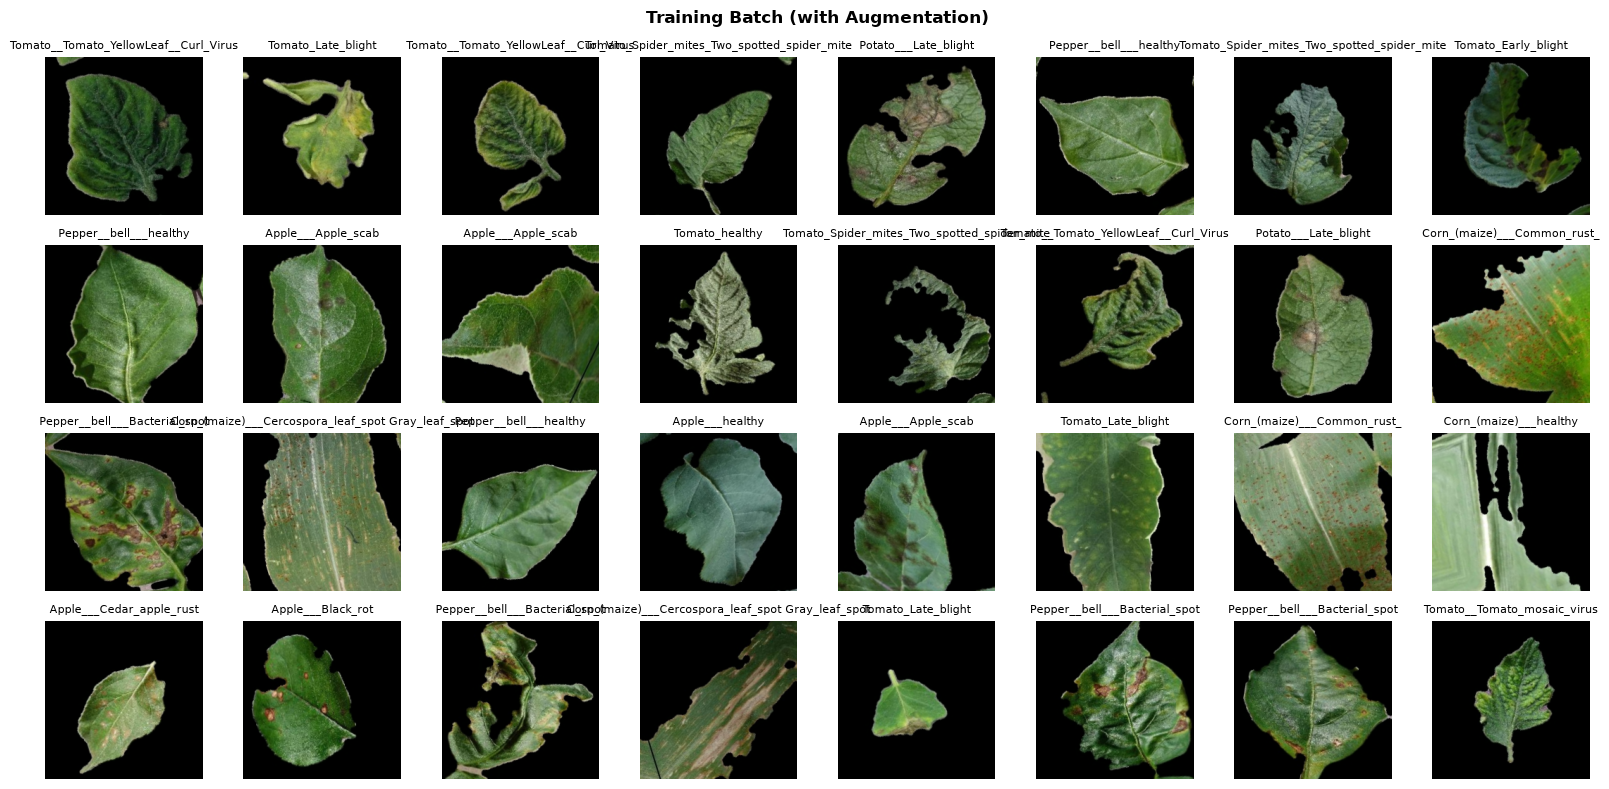

In [16]:
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for images, labels in train_ds.take(1):
    for i in range(min(32, len(axes))):
        img = images[i].numpy()
        label_idx = np.argmax(labels[i].numpy())
        class_name = class_names[label_idx]
        
        axes[i].imshow(img)
        axes[i].set_title(class_name, fontsize=8)
        axes[i].axis('off')

plt.suptitle('Training Batch (with Augmentation)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Save Config

In [17]:
ds_config = {
    'img_size': list(IMG_SIZE),
    'batch_size': BATCH_SIZE,
    'num_classes': NUM_CLASSES,
    'class_names': class_names,
    'augmentation': {
        'flip': 'horizontal_and_vertical',
        'rotation': 0.2,
        'zoom': 0.2,
        'brightness': 0.2,
        'contrast': 0.2
    },
    'normalization': 'divide by 255'
}

with open(OUTPUTS_DIR / 'dataset_config.json', 'w') as f:
    json.dump(ds_config, f, indent=2)

print(f"Config saved to {OUTPUTS_DIR / 'dataset_config.json'}")

Config saved to outputs\dataset_config.json


## Summary

In [19]:
print("\n" + "="*60)
print("PREPROCESSING PIPELINE READY")
print("="*60)
print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Classes: {NUM_CLASSES}")


PREPROCESSING PIPELINE READY
Image size: (224, 224)
Batch size: 32
Classes: 23
